# huARdb CPIc_C2 processed-data reproduction

## tl;dr

After GEX QC, **4,052** cells remain; **2,849** are strict 1TRA+1TRB hcT cells. They form **1,587** exact paired CDR3-nt clonotypes, including **334** expanded clones. The largest clone is `clonotype_000001` with **103** cells.

## Context & Methods

This companion notebook reads pipeline outputs rather than recomputing the full Scanpy workflow. The executable source of truth is `run_pipeline.sh` and `scripts/`.

### Key Assumptions

- TCR barcodes ending in `-C2` are explicitly mapped to the matching GEX `-1` suffix.
- Strict hcT means productive, high-confidence, exactly one TRA and one TRB, both with CDR3 nucleotide sequence.
- Expanded means clone size ≥2.
- Clone-level DEG is exploratory and is not donor-aware inference.

## Data

### 1. Load audited result tables

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd()
summary = pd.read_csv(ROOT / 'results/tables/analysis_summary.tsv', sep='\t')
clones = pd.read_csv(ROOT / 'results/tables/clonotypes.tsv', sep='\t')
scirpy_validation = pd.read_csv(ROOT / 'results/qc/scirpy_clonotype_validation.tsv', sep='\t')
display(summary)

,n_cells,tcr_associated_cells,strict_hct_cells,paired_TRA_TRB_rate,n_clonotypes,n_singletons,n_expanded_clones,largest_clonotype_id,largest_clone_size,largest_clone_fraction,shannon_diversity,simpson_diversity,hill_q0,hill_q1,hill_q2
0,4052,3707,2849,0.768546,1587,1253,334,clonotype_000001,103,0.036153,6.759168,0.995853,1587,861.924646,241.11936


## Results

### 2. Inspect the largest nucleotide clonotypes

In [2]:
columns = ['clonotype_id', 'clone_size', 'TRA_v', 'TRA_cdr3_aa', 'TRA_cdr3_nt', 'TRB_v', 'TRB_cdr3_aa', 'TRB_cdr3_nt']
display(clones.loc[:, columns].head(10))

,clonotype_id,clone_size,TRA_v,TRA_cdr3_aa,TRA_cdr3_nt,TRB_v,TRB_cdr3_aa,TRB_cdr3_nt
0,clonotype_000001,103,TRAV29/DV5,CAAKQTDKLIF,TGTGCAGCAAAGCAGACCGACAAGCTCATCTTT,TRBV7-2,CASSFGPGIQPQHF,TGTGCCAGCAGCTTTGGTCCAGGAATTCAGCCCCAGCATTTT
1,clonotype_000002,79,TRAV12-3,CAMTITGNQFYF,TGTGCAATGACCATCACCGGTAACCAGTTCTATTTT,TRBV7-9,CASRLDGSEYGYTF,TGTGCCAGCAGGCTAGACGGTTCGGAGTATGGCTACACCTTC
2,clonotype_000003,66,TRAV12-2,CAVSGFGNVLHC,TGTGCCGTGAGCGGCTTTGGGAATGTGCTGCATTGC,TRBV27,CASSPAPGTGRFIQYF,TGTGCCAGCAGTCCCGCCCCCGGGACAGGGAGATTCATTCAGTACTTC
3,clonotype_000004,42,TRAV8-2,CVVSDRYGGATNKLIF,TGTGTTGTGAGTGATCGATATGGTGGTGCTACAAACAAGCTCATCTTT,TRBV5-1,CASSSTGTSGGEGQFF,TGCGCCAGCAGCTCTACCGGGACTAGCGGGGGGGAGGGGCAGTTCTTC
4,clonotype_000005,32,TRAV29/DV5,CAASVIQGAQKLVF,TGTGCAGCAAGCGTCATTCAGGGAGCCCAGAAGCTGGTATTT,TRBV20-1,CSANPDSGYSYEQYF,TGCAGTGCTAACCCCGATAGCGGCTACTCCTACGAGCAGTACTTC
5,clonotype_000006,22,TRAV12-3,CAMSGGQKLLF,TGTGCAATGAGCGGCGGCCAGAAGCTGCTCTTT,TRBV7-9,CASSFKGEQYF,TGTGCCAGCAGCTTTAAGGGCGAGCAGTACTTC
6,clonotype_000007,20,TRAV8-2,CVVSERYSSASKIIF,TGTGTTGTGAGTGAGAGGTACAGCAGTGCTTCCAAGATAATCTTT,TRBV15,CATSRDRRGSYEQYF,TGTGCCACCAGCAGAGATCGGCGGGGGTCCTACGAGCAGTACTTC
7,clonotype_000008,19,TRAV29/DV5,CAANTDKLIF,TGTGCAGCCAACACCGACAAGCTCATCTTT,TRBV12-4,CASTAWARGNEQFF,TGTGCCAGCACCGCTTGGGCCCGGGGGAATGAGCAGTTCTTC
8,clonotype_000009,19,TRAV38-1,CAFIDNNDMRF,TGTGCTTTCATTGATAACAATGACATGCGCTTT,TRBV6-2,CASSYEGDLRGKLFF,TGTGCCAGCAGTTACGAGGGGGACCTTCGCGGGAAACTGTTTTTT
9,clonotype_000010,19,TRAV8-2,CVVSDPFSGGYNKLIF,TGTGTTGTGAGTGACCCCTTTTCTGGTGGCTACAATAAGCTGATTTTT,TRBV2,CASSERGNTDTQYF,TGTGCCAGCAGTGAGAGGGGGAACACAGATACGCAGTATTTT


### 3. Confirm manual-versus-Scirpy validation

In [3]:
display(scirpy_validation)
assert scirpy_validation['match'].all()

,metric,manual,scirpy,match
0,n_clonotypes,1587,1587,True
1,n_singletons,1253,1253,True
2,n_expanded,334,334,True
3,largest_clone_size,103,103,True
4,top10_sizes,"103,79,66,42,32,22,20,19,19,19","103,79,66,42,32,22,20,19,19,19",True
5,barcode_membership,2849,2849,True


### 4. Display the top-clone transcriptome projection

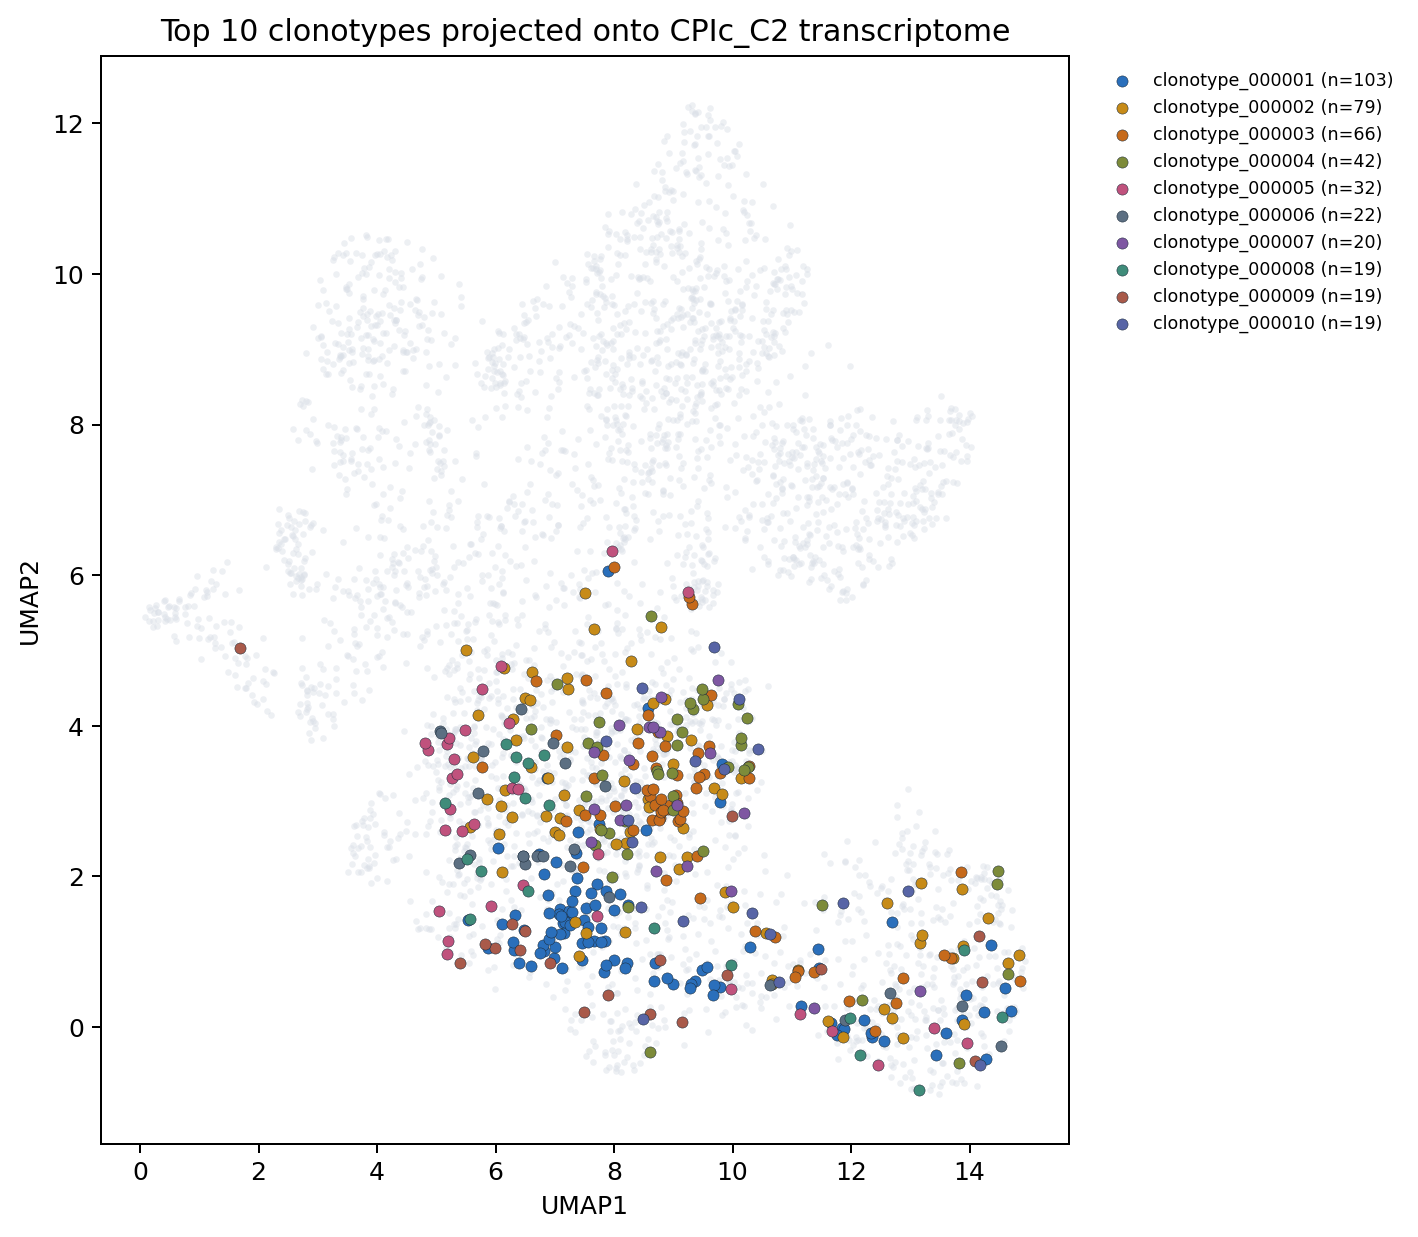

In [4]:
Image(filename=str(ROOT / 'results/figures/umap_top_clones.png'))

## Takeaways

- Barcode integration is nearly complete but not perfect; unmatched GEX-only and TCR-only cells remain visible in the merge audit.
- Most clonotypes are singletons, while a smaller expanded set creates a long-tailed clone-size distribution.
- Expanded clones occupy non-identical Leiden/marker states, supporting coupled clonotype–transcriptome exploration.
- A clonotype is a receptor-sequence grouping, not proof of antigen specificity.